# Exploratory Data Analysis

Understanding the shape, trends, and problem areas in the DataCo supply chain before building any models.

Dataset: Jan 2015 – Jan 2018  ·  180,519 order lines  ·  5 markets


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.family": "sans-serif",
})

C = {"navy":"#0F1E35","blue":"#2563EB","green":"#16A34A","red":"#DC2626","amber":"#D97706","slate":"#94A3B8"}


In [2]:
df = pd.read_csv("../data/processed/clean_supply_chain.csv")
df["order_date"]    = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

print(f"{len(df):,} rows  x  {df.shape[1]} columns")
print(f"orders: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"unique orders: {df['order_id'].nunique():,}")
print(f"products: {df['product_name'].nunique()}  |  categories: {df['category_name'].nunique()}")
print(f"markets: {df['market'].unique()}")


180,519 rows  x  50 columns
orders: 2015-01-01 to 2018-01-31
unique orders: 65,752
products: 118  |  categories: 50
markets: ['Pacific Asia' 'USCA' 'Africa' 'Europe' 'LATAM']


## Order volume and revenue, Jan 2015 – Sep 2017


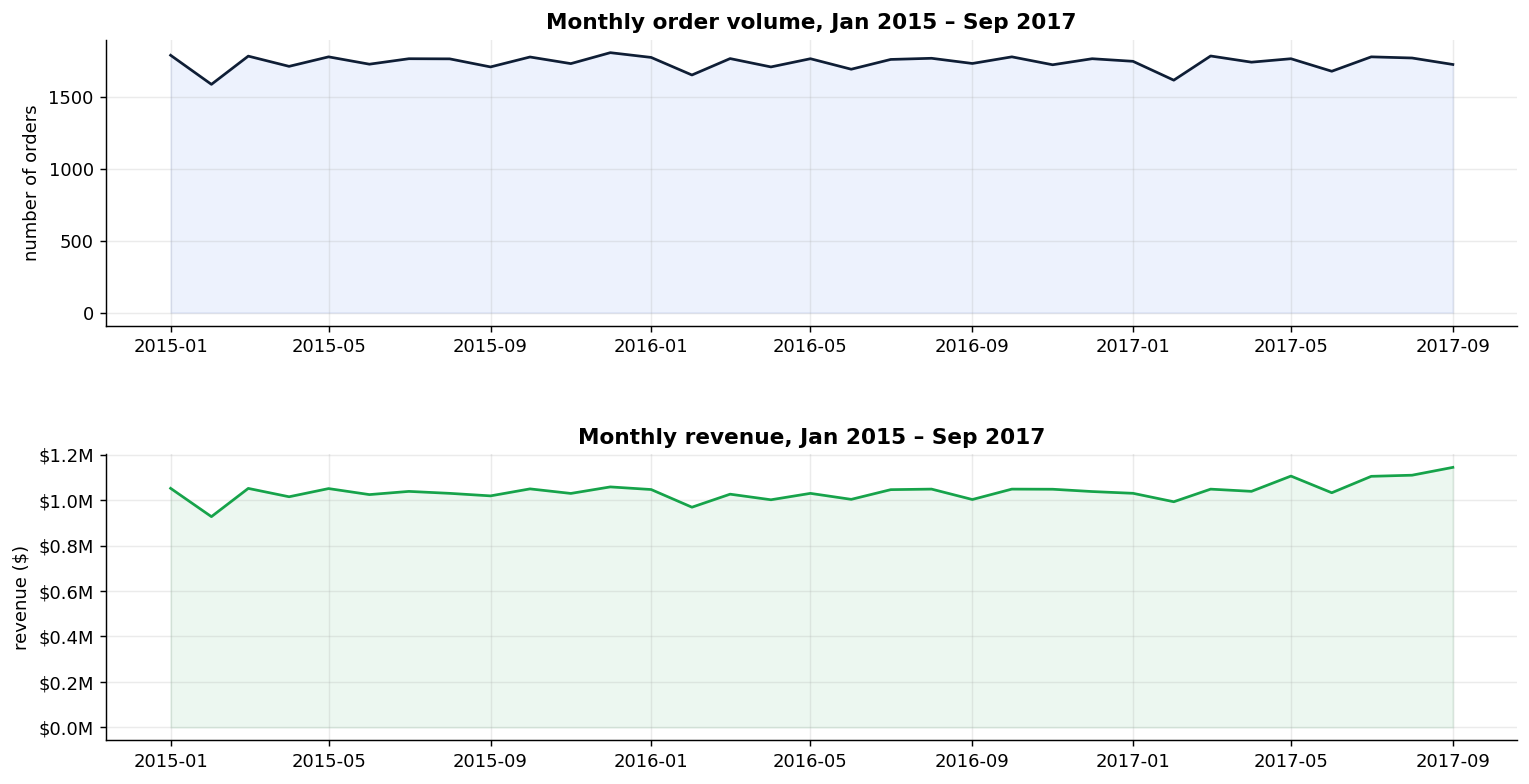

In [3]:
monthly = (
    df[df["order_date"] < "2017-10-01"]
    .groupby("order_month")
    .agg(orders=("order_id","nunique"), revenue=("sales","sum"))
    .reset_index()
)
monthly["order_month"] = pd.to_datetime(monthly["order_month"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"hspace": 0.45})

axes[0].fill_between(monthly["order_month"], monthly["orders"], alpha=0.08, color=C["blue"])
axes[0].plot(monthly["order_month"], monthly["orders"], color=C["navy"], linewidth=1.5)
axes[0].set_title("Monthly order volume, Jan 2015 – Sep 2017", fontweight="bold")
axes[0].set_ylabel("number of orders")

axes[1].fill_between(monthly["order_month"], monthly["revenue"], alpha=0.08, color=C["green"])
axes[1].plot(monthly["order_month"], monthly["revenue"], color=C["green"], linewidth=1.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
axes[1].set_title("Monthly revenue, Jan 2015 – Sep 2017", fontweight="bold")
axes[1].set_ylabel("revenue ($)")

plt.tight_layout()
plt.show()


## Late delivery, 2015 – 2017

Late delivery rate is the most actionable operational metric in this dataset. Worth understanding where it comes from.


Overall late delivery rate: 54.8%


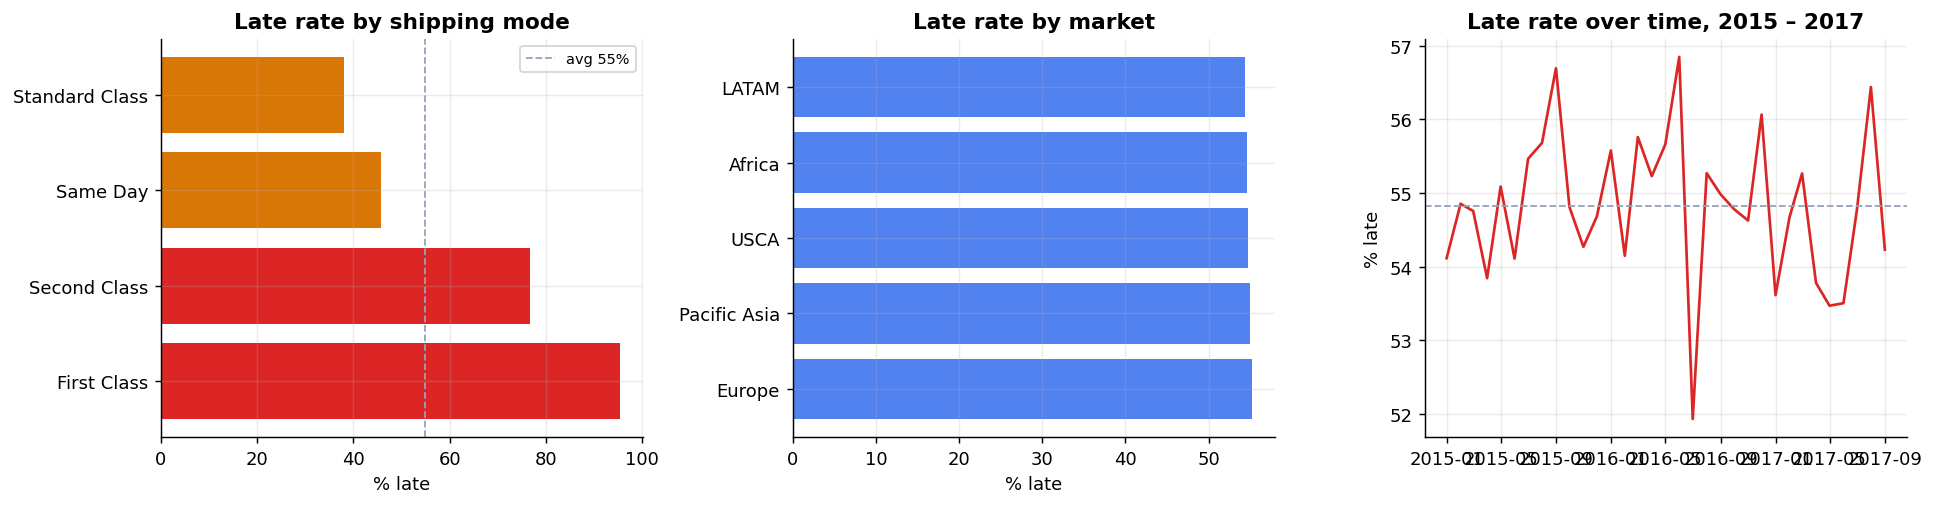

In [4]:
late_rate = df["is_late"].mean() * 100
print(f"Overall late delivery rate: {late_rate:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By shipping mode
by_mode = df.groupby("shipping_mode")["is_late"].mean().sort_values(ascending=False) * 100
axes[0].barh(by_mode.index, by_mode.values,
             color=[C["red"] if v > 50 else C["amber"] if v > 30 else C["green"] for v in by_mode.values])
axes[0].set_title("Late rate by shipping mode", fontweight="bold")
axes[0].set_xlabel("% late")
axes[0].axvline(late_rate, color=C["slate"], linestyle="--", linewidth=1, label=f"avg {late_rate:.0f}%")
axes[0].legend(fontsize=8)

# By market
by_market = df.groupby("market")["is_late"].mean().sort_values(ascending=False) * 100
axes[1].barh(by_market.index, by_market.values, color=C["blue"], alpha=0.8)
axes[1].set_title("Late rate by market", fontweight="bold")
axes[1].set_xlabel("% late")

# Trend over time
late_monthly = df[df["order_date"] < "2017-10-01"].groupby("order_month")["is_late"].mean().reset_index()
late_monthly["order_month"] = pd.to_datetime(late_monthly["order_month"])
axes[2].plot(late_monthly["order_month"], late_monthly["is_late"] * 100,
             color=C["red"], linewidth=1.5)
axes[2].axhline(late_rate, color=C["slate"], linestyle="--", linewidth=1)
axes[2].set_title("Late rate over time, 2015 – 2017", fontweight="bold")
axes[2].set_ylabel("% late")

plt.tight_layout()
plt.show()


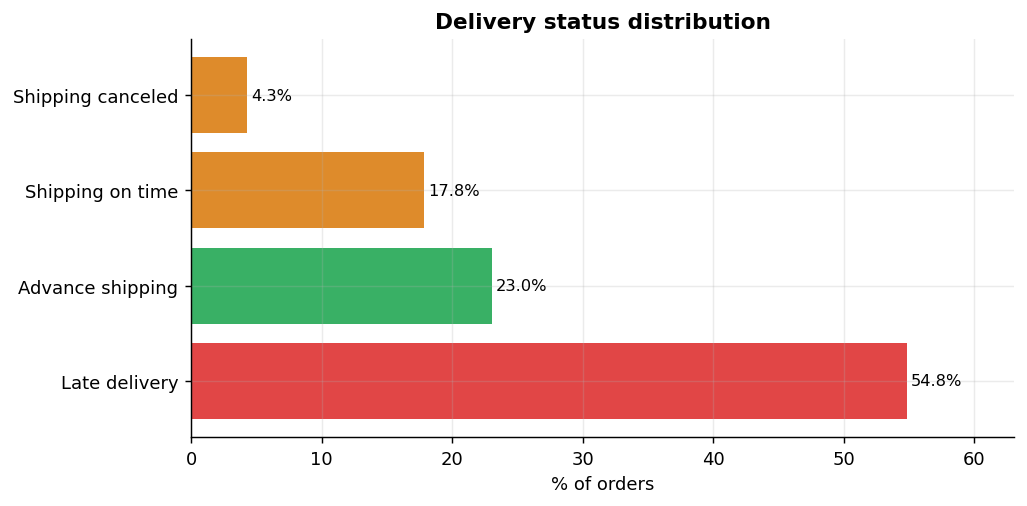

In [5]:
# Delivery status breakdown
status = df["delivery_status"].value_counts(normalize=True) * 100
colors = [C["red"] if "Late" in s else C["green"] if "Advance" in s else C["amber"] for s in status.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(status.index, status.values, color=colors, alpha=0.85)
for bar, v in zip(bars, status.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% of orders")
ax.set_title("Delivery status distribution", fontweight="bold")
ax.set_xlim(0, status.values.max() * 1.15)
plt.tight_layout()
plt.show()


## Market and region, 2015 – 2018


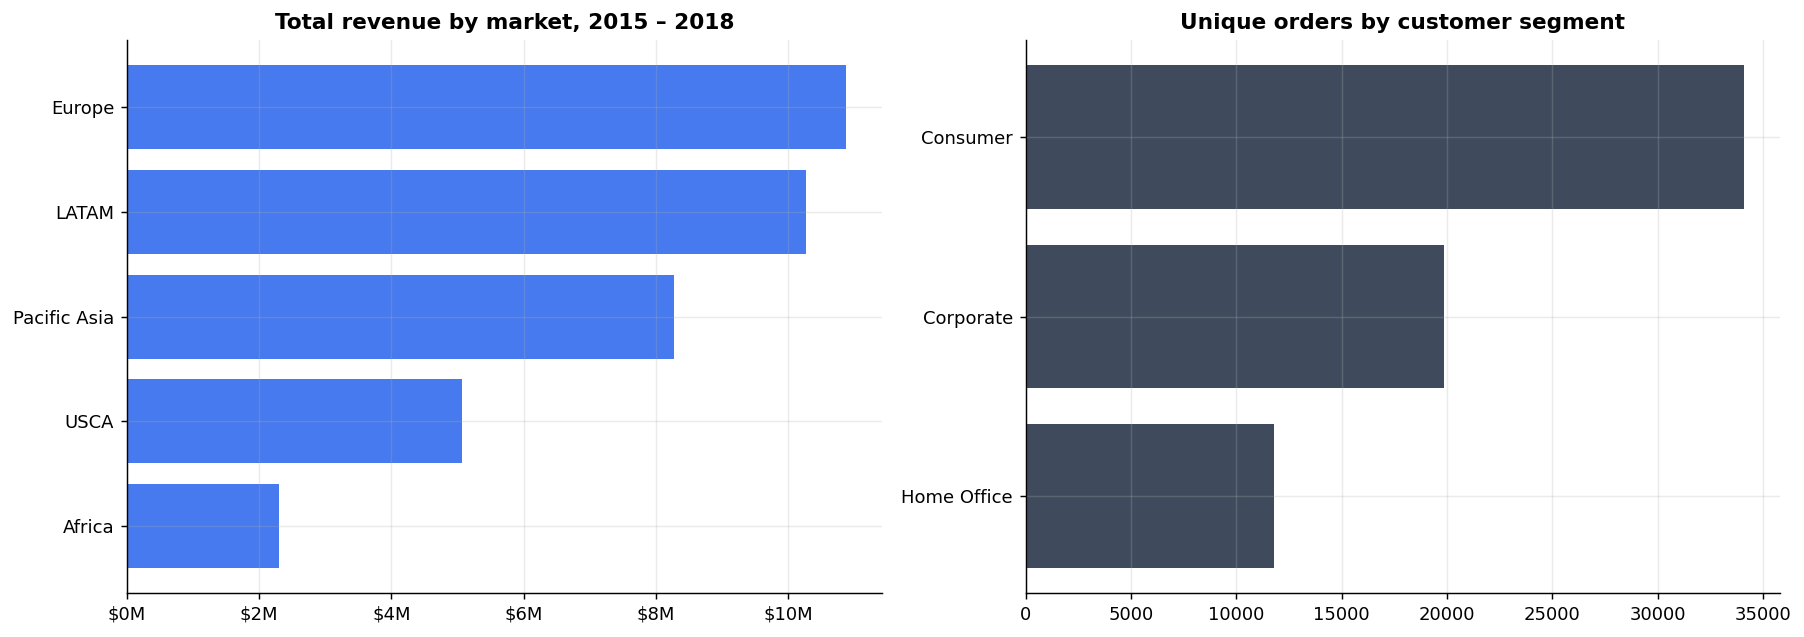

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by market
mkt_rev = df.groupby("market")["sales"].sum().sort_values()
axes[0].barh(mkt_rev.index, mkt_rev.values, color=C["blue"], alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.0f}M"))
axes[0].set_title("Total revenue by market, 2015 – 2018", fontweight="bold")

# Orders by customer segment
seg = df.groupby("customer_segment")["order_id"].nunique().sort_values()
axes[1].barh(seg.index, seg.values, color=C["navy"], alpha=0.8)
axes[1].set_title("Unique orders by customer segment", fontweight="bold")

plt.tight_layout()
plt.show()


## Product and category


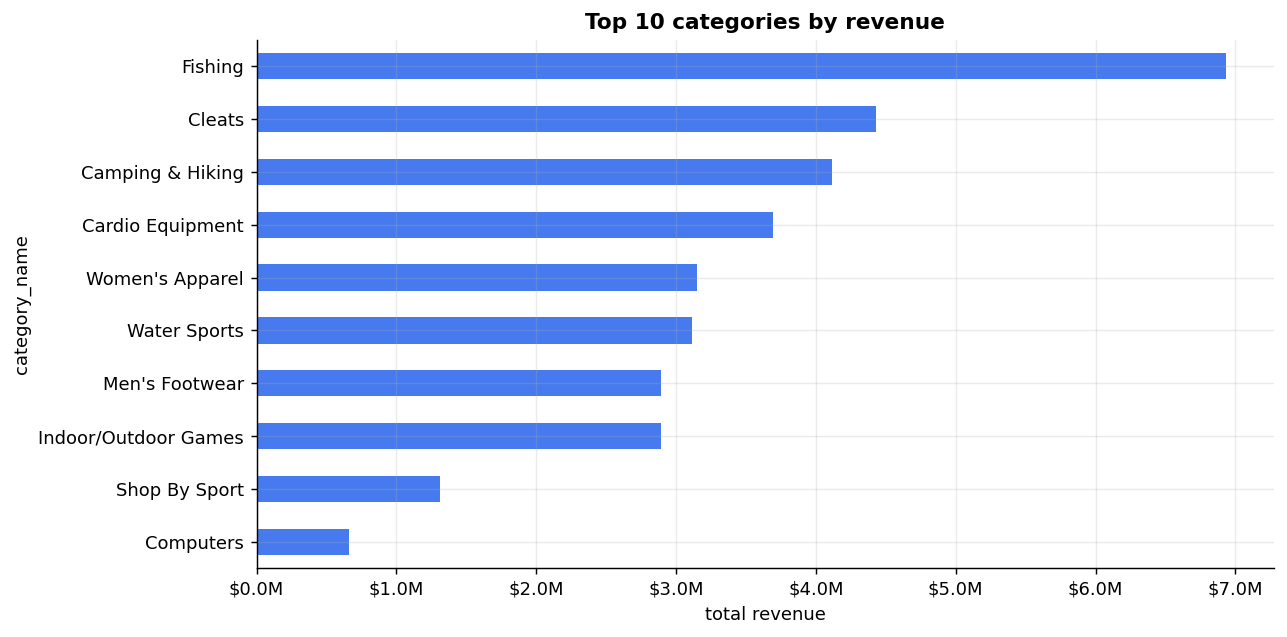

In [7]:
# Top 10 categories by revenue
cat_rev = (
    df.groupby("category_name")["sales"].sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
cat_rev.sort_values().plot(kind="barh", ax=ax, color=C["blue"], alpha=0.85)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
ax.set_title("Top 10 categories by revenue", fontweight="bold")
ax.set_xlabel("total revenue")
plt.tight_layout()
plt.show()


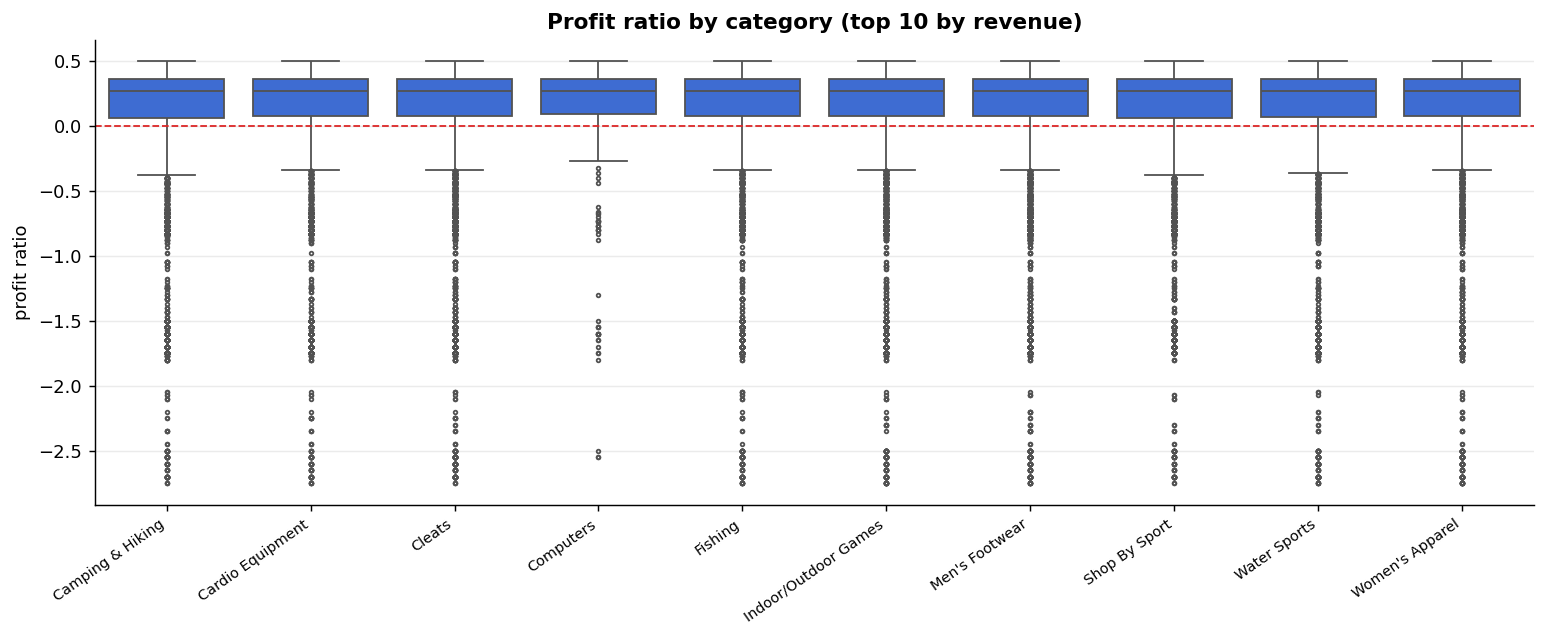

In [8]:
# Profit ratio distribution by category (top 10)
top_cats = df.groupby("category_name")["sales"].sum().nlargest(10).index
plot_df = df[df["category_name"].isin(top_cats)]

fig, ax = plt.subplots(figsize=(12, 5))
order = plot_df.groupby("category_name")["order_item_profit_ratio"].median().sort_values().index
sns.boxplot(data=plot_df, x="category_name", y="order_item_profit_ratio",
            order=order, ax=ax, color=C["blue"], fliersize=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
ax.axhline(0, color=C["red"], linestyle="--", linewidth=1)
ax.set_title("Profit ratio by category (top 10 by revenue)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("profit ratio")
plt.tight_layout()
plt.show()


## Shipping delay distribution


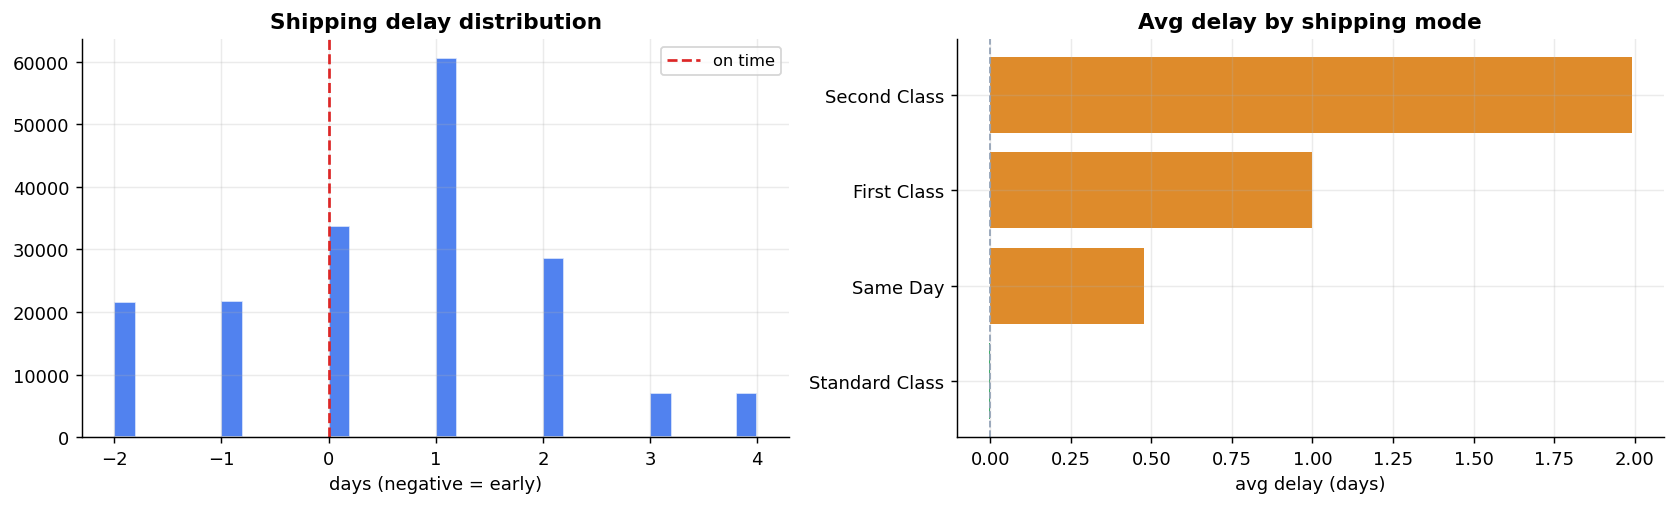

avg delay : 0.57 days
% on time : 42.7%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of shipping delay
axes[0].hist(df["shipping_delay"].clip(-5, 10), bins=30,
             color=C["blue"], alpha=0.8, edgecolor="white")
axes[0].axvline(0, color=C["red"], linestyle="--", linewidth=1.5, label="on time")
axes[0].set_title("Shipping delay distribution", fontweight="bold")
axes[0].set_xlabel("days (negative = early)")
axes[0].legend(fontsize=9)

# Average delay by shipping mode
delay_mode = df.groupby("shipping_mode")["shipping_delay"].mean().sort_values()
colors = [C["green"] if v <= 0 else C["amber"] if v < 2 else C["red"] for v in delay_mode.values]
axes[1].barh(delay_mode.index, delay_mode.values, color=colors, alpha=0.85)
axes[1].axvline(0, color=C["slate"], linestyle="--", linewidth=1)
axes[1].set_title("Avg delay by shipping mode", fontweight="bold")
axes[1].set_xlabel("avg delay (days)")

plt.tight_layout()
plt.show()

print(f"avg delay : {df['shipping_delay'].mean():.2f} days")
print(f"% on time : {(df['shipping_delay'] <= 0).mean()*100:.1f}%")


## Key findings

**~55% of orders are delivered late.** First Class and Same Day shipping modes have the highest late rates, likely because customers chose them for speed and any delay is more visible.

**LATAM and Pacific Asia drive the most revenue** but also show higher late delivery rates than Europe, suggesting regional logistics gaps.

**Demand is stable month to month** (low CV on the weekly series, confirmed in the forecasting notebook). No strong seasonal spike, which is consistent with a B2B-heavy order mix across multiple product categories.

**Several categories run negative or near-zero profit ratios** on individual orders. Worth flagging for the business but outside the scope of the forecasting model.
